# Imports

In [3107]:
%pip install -q -r requirements.txt

Note: you may need to restart the kernel to use updated packages.


In [3108]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from statsmodels.tsa.stattools import adfuller
from statsmodels.tools import add_constant
import plotly.graph_objects as go
from statsmodels.regression.linear_model import OLS
from statsmodels.tsa.vector_ar.vecm import coint_johansen
from datetime import datetime
from dateutil.relativedelta import relativedelta
import itertools

# Constants

## Control

In [3109]:
FETCH_DATA = False
SAVE_RESULT = True
PLOT_RESULT = False
PLOT_SPREAD = False

## Dataset

In [3110]:
# START_DATE = datetime(2024, 12, 1)
# END_DATE = datetime(2025, 12, 1)
START_DATE = "2024-12-01"
END_DATE = "2025-12-01"

TOP_50 = ["BTC", "ETH", "BNB", "XRP", "SOL", "TRX", "DOGE", "ADA", "BCH", "LINK", "RAIN", "XMR", "XLM", "ZEC", "LEO", "LTC", "DAI", "SUI", "AVAX", "HBAR", "SHIB", "NIGHT", "STETH", "UNI", "DOT", "AAVE", "CC", "BGB", "ASTER", "PI", "ENA", "SKY", "KCS", "WLD", "ONDO", "KAS", "APT", "ARB", "ALGO", "FLR", "ATOM", "FIL", "QNT", "VET", "M", "CBBTC", "WBT", "JUP", "LIT"]

## Routes

In [3111]:
TICKERS_DIR = "tickers"
PLOTS_DIR = "plots"

# Configuration

In [3112]:
pd.set_option('display.max_rows', 500)
pd.set_option('display.precision', 2)
pd.set_option('display.float_format', '{:.2f}'.format)

# Functions

In [3113]:
def fetch_from_yfinance(ticker: str, route: str, start_date, end_date, fetch: bool=True):
    if fetch:
        s = ticker.upper().strip()
        yahoo_format = s if s.endswith("-USD") else f"{s}-USD"
        
        df1 = yf.download(
            tickers=yahoo_format,
            start=start_date,
            end=end_date,
            auto_adjust=False
        )
        df2 = yf.download(
            tickers=ticker,
            start=start_date,
            end=end_date,
            auto_adjust=False
        )
        
        if len(df1) > 0:
            df = df1
        if len(df2) > 0:
            df = df2
            
        df.to_csv(route)
        df = pd.read_csv(route, skiprows=[1, 2], header=0)
        df = df.rename(columns={'Price': 'Date'})
        df = df.set_index('Date')
        df.to_csv(route)
    else:
        df = pd.read_csv(route)
    return df

In [3114]:
def filter_ticker(ticker, start: str, end: str):
    filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
    df_full = fetch_from_yfinance(ticker, filename, START_DATE, END_DATE, FETCH_DATA)
    df_full['Date'] = pd.to_datetime(df_full['Date'])
    start_ts = pd.to_datetime(start)
    end_ts = pd.to_datetime(end)

    mask = (df_full['Date'] >= start_ts) & (df_full['Date'] <= end_ts)
    df = df_full.loc[mask].copy()
    df = df.reset_index()
    df = df.drop(columns=['index'])
    return df

In [3115]:
def adf_test(ticker, df, column='Close'):
    if df is None or df.empty or column not in df.columns:
        return {"Ticker": ticker, "Error": "Missing Data"}

    series = df[column].dropna()
    
    if len(series) < 20:
        return {"Ticker": ticker, "Error": f"Insufficient data points: {len(series)}"}

    result = adfuller(series, autolag='AIC')
    
    adf_output = {
        "Ticker": ticker,
        "ADF Statistic": round(result[0], 4),
        "p-value": round(result[1], 4),
        "Stationary": result[1] < 0.05,
        "Lags Used": result[2],
        "Observations": result[3]
    }
    
    return adf_output

In [3116]:
def hurst_exponent(series, q=2.0, max_lag=None, min_lag=2):
    series = np.asarray(series, dtype=float)
    n = len(series)

    if max_lag is None:
        max_lag = n // 4
    if max_lag <= min_lag:
        raise ValueError("max_lag must be > min_lag")

    # Lags
    lags = np.arange(min_lag, max_lag)

    # K_q values for each lag
    K = np.zeros_like(lags, dtype=float)

    for i, lag in enumerate(lags):
        diffs = np.abs(series[lag:] - series[:-lag])
        K[i] = np.mean(diffs ** q)

    # Fit log–log to estimate slope
    log_lags = np.log(lags)
    log_K = np.log(K)

    slope, _ = np.polyfit(log_lags, log_K, 1)

    Hurst = slope / q
    
    return Hurst

In [3117]:
def half_life(series):
    series = series.dropna()
    
    if len(series) < 10:
        print("For half-life series must be longer than 10 values")
        return np.nan
    
    # Create lagged series
    price_lag = series.shift(1)
    price_diff = series - price_lag
    
    # Remove NaN values
    valid_data = pd.concat([price_lag, price_diff], axis=1).dropna()
    X = add_constant(valid_data.iloc[:, 0])
    y = valid_data.iloc[:, 1]
    
    # Perform OLS regression
    try:
        model = OLS(y, X)
        results = model.fit()
        
        beta = results.params.iloc[1]
        
        half_life = -np.log(2) / np.log(1 + beta) if (1 + beta) > 0 else np.nan
        
        return half_life
    except Exception as e:
        print(f"Error occured while calculating half life: ${e}")
        return np.nan

In [3118]:
def store_series_plot(df, ticker: str, route: str = PLOTS_DIR):
    if not os.path.exists(route):
        os.makedirs(route)
        
    x_axis = df['Date'] if 'Date' in df.columns else df.index
        
    fig = go.Figure(data=[go.Candlestick(
        x=x_axis,
        open=df['Open'],
        high=df['High'],
        low=df['Low'],
        close=df['Close'],
    )])

    fig.update_layout(
        xaxis_title='Date',
        yaxis_title='Price',
        xaxis_rangeslider_visible=False,
        template='plotly_white',
        height=900,
        width=1600,
        showlegend=False
    )
    
    save_path = os.path.join(route, f"{ticker}.png")
    fig.write_image(save_path)

In [3119]:
def johansen_test(df_combined, det_order=0, k_ar_diff=1):
    df_clean = df_combined.dropna()
    
    if df_clean.shape[1] < 2:
        print("Need at least 2 series for Johansen test.")
        return None

    result = coint_johansen(df_clean, det_order, k_ar_diff)
    
    traces = result.lr1
    cvts = result.cvt
    eigenvalues = result.eig
    
    summary = []
    for i in range(len(traces)):
        is_cointegrated = traces[i] > cvts[i, 1]
        summary.append({
            "Rank": i + 1,
            "Trace Stat": round(traces[i], 4),
            "CV 95%": round(cvts[i, 1], 4),
            "Significant": is_cointegrated
        })
    
    return pd.DataFrame(summary), result.evec[:, 0]

# Fetch data

## Fetch merket data of top 50 crypto

In [3120]:
dfs = {}
if not os.path.exists(TICKERS_DIR):
    os.makedirs(TICKERS_DIR)
    print(f"Created directory: {TICKERS_DIR}")
for ticker in TOP_50:
    filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
    try:
        # df_full = fetch_from_yfinance(ticker, filename, START_DATE, END_DATE, FETCH_DATA)
        # # print(df_full)
        # df_full['Date'] = pd.to_datetime(df_full['Date'])
        # # dfs[ticker] = df_full.copy()
        # start_ts = pd.to_datetime(START_DATE)
        # end_ts = pd.to_datetime(END_DATE)

        # mask = (df_full['Date'] >= start_ts) & (df_full['Date'] <= end_ts)
        # dfs[ticker] = df_full.loc[mask].copy()
        # dfs[ticker] = dfs[ticker].reset_index()
        # dfs[ticker] = dfs[ticker].drop(columns=['index'])
        dfs[ticker] = filter_ticker(ticker, START_DATE, END_DATE)
        # dfs[ticker] = df_full.loc[pd.to_datetime(START_DATE) : pd.to_datetime(END_DATE)].copy()
        if PLOT_RESULT:
            store_series_plot(dfs[ticker], ticker)
    except Exception as e:
        print(f"Failed to fetch {ticker}: {e}")

# Calculate parameters

In [3121]:
summary_results = []

for ticker in TOP_50:
    filename = os.path.join(TICKERS_DIR, f"{ticker}.csv")
    try:
        # df_full = fetch_from_yfinance(ticker, filename, START_DATE, END_DATE, FETCH_DATA)
        # df_full.index = pd.to_datetime(df_full['Date'])
        # df = df_full.loc[START_DATE : END_DATE].copy()
        df = filter_ticker(ticker, START_DATE, END_DATE)
        res = adf_test(ticker, df)
        res['hurst'] = hurst_exponent(df['Close'])
        res['half_life'] = half_life(df['Close'])
        summary_results.append(res)
        
    except Exception as e:
        print(f"Failed {ticker}: {e}")

Failed XRP: max_lag must be > min_lag


In [3122]:
summary_df = pd.DataFrame(summary_results)
summary_df.head()

,Ticker,ADF Statistic,p-value,Stationary,Lags Used,Observations,hurst,half_life
0,BTC,-1.76,0.40,False,0,248,0.45,26.13
1,ETH,-1.21,0.67,False,1,247,0.61,47.29
2,BNB,-1.03,0.74,False,8,356,0.47,64.48
3,SOL,-2.11,0.24,False,1,247,0.49,14.62
4,TRX,-0.17,0.94,False,12,236,0.54,1693.14


## Filter tickers with p-value $\le$ 0.05

In [3123]:
stationary_df = summary_df[summary_df['p-value'] <= 0.05].copy()
stationary_df = stationary_df.sort_values(by='p-value')
print("Stationary tickers:", len(stationary_df))
stationary_df

Stationary tickers: 11


,Ticker,ADF Statistic,p-value,Stationary,Lags Used,Observations,hurst,half_life
15,DAI,-5.85,0.00,True,3,361,0.02,0.70
46,JUP,-7.97,0.00,True,3,361,0.06,0.68
23,DOT,-4.64,0.00,True,6,358,0.46,33.12
16,SUI,-4.50,0.00,True,0,248,0.20,4.16
14,LTC,-4.20,0.00,True,0,248,0.14,5.70
12,ZEC,-3.74,0.00,True,13,351,0.56,2855.26
40,FIL,-3.74,0.00,True,4,360,0.45,32.89
20,NIGHT,-3.60,0.01,True,16,299,0.45,30.99
32,WLD,-3.32,0.01,True,2,362,0.48,24.15
11,XLM,-3.15,0.02,True,0,364,0.41,18.64


In [3124]:
half_life_df = stationary_df.sort_values(by='half_life')
half_life_df

,Ticker,ADF Statistic,p-value,Stationary,Lags Used,Observations,hurst,half_life
46,JUP,-7.97,0.00,True,3,361,0.06,0.68
15,DAI,-5.85,0.00,True,3,361,0.02,0.70
16,SUI,-4.50,0.00,True,0,248,0.20,4.16
14,LTC,-4.20,0.00,True,0,248,0.14,5.70
11,XLM,-3.15,0.02,True,0,364,0.41,18.64
32,WLD,-3.32,0.01,True,2,362,0.48,24.15
19,SHIB,-3.06,0.03,True,2,362,0.50,24.64
20,NIGHT,-3.60,0.01,True,16,299,0.45,30.99
40,FIL,-3.74,0.00,True,4,360,0.45,32.89
23,DOT,-4.64,0.00,True,6,358,0.46,33.12


# Mix dfs

In [3125]:
found_combinations = []
non_stationary_tickers = summary_df[summary_df['p-value'] > 0.05]['Ticker'].tolist()

for r in [4, 5]:
    if len(found_combinations) >= 10: break
    
    potential_groups = list(itertools.combinations(non_stationary_tickers[:20], r)) 

    for group in potential_groups:
        if len(found_combinations) >= 10: break
        
        combined_data = pd.concat([dfs[t]['Close'] for t in group], axis=1).dropna()
        
        res = coint_johansen(combined_data, det_order=0, k_ar_diff=1)
        
        if res.lr1[0] > res.cvt[0, 1]: 
            weights = res.evec[:, 0] 
            found_combinations.append({
                'group': group,
                'weights': weights,
                'johansen_stat': res.lr1[0]
            })

In [3126]:
results_with_hl = []

for item in found_combinations:
    group = item['group']
    weights = item['weights']
    
    spread_series = pd.Series(0, index=dfs[group[0]].index)
    for i, ticker in enumerate(group):
        spread_series += dfs[ticker]['Close'] * weights[i]
    
    hl = half_life(spread_series)
    if hl is not np.nan and hl > 1:
        results_with_hl.append({
            'group': group,
            'half_life': hl,
            'spread_series': spread_series,
            'weights': weights
        })

top_5_combinations = sorted(results_with_hl, key=lambda x: x['half_life'])[:5]

In [3127]:
list(map(lambda q: q['half_life'], top_5_combinations))

[np.float64(3.543142332228816),
 np.float64(4.157514881765108),
 np.float64(4.730136170985604),
 np.float64(5.241756653256941),
 np.float64(5.489304013474341)]

In [3128]:
def plot_spread_candlestick(group, weights, dfs, folder="plots"):
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    
    # Close and Open are straightforward linear combinations
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    # For High and Low, we must check the sign of the weight
    spread_high = 0
    spread_low = 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            spread_high += dfs[ticker]['High'] * weights[i]
            spread_low  += dfs[ticker]['Low'] * weights[i]
        else:
            # If weight is negative, the asset's 'Low' contributes to the spread's 'High'
            spread_high += dfs[ticker]['Low'] * weights[i]
            spread_low  += dfs[ticker]['High'] * weights[i]
            
    spread_df['High'] = spread_high
    spread_df['Low']  = spread_low
    
    # Store the result
    ticker_name = f"Spread_{'_'.join(group)}"
    store_series_plot(spread_df, ticker_name, folder)

In [3129]:
import plotly.graph_objects as go
import os

def plot_overlay_normalized_candlesticks(group, dfs, ticker_name, folder="plots"):
    """
    Plots multiple normalized candlestick series on a single shared axis.
    """
    fig = go.Figure()

    # Distinct color pairs for up/down candles per ticker
    color_pairs = [
        {'inc': '#26a69a', 'dec': '#ef5350'}, # Teal / Red
        {'inc': '#2196f3', 'dec': '#f44336'}, # Blue / Bright Red
        {'inc': '#9c27b0', 'dec': '#e91e63'}, # Purple / Pink
        {'inc': '#ff9800', 'dec': '#795548'}, # Orange / Brown
        {'inc': '#4caf50', 'dec': '#ffeb3b'}  # Green / Yellow
    ]

    for i, ticker in enumerate(group):
        if ticker not in dfs:
            continue
            
        df = dfs[ticker].copy()
        
        # 1. Normalization: Divide all OHLC columns by the first Close price
        base_price = df['Close'].iloc[0]
        df_norm = df[['Open', 'High', 'Low', 'Close']] / base_price
        
        # 2. Select colors for this specific ticker
        colors = color_pairs[i % len(color_pairs)]
        
        # 3. Add the trace
        fig.add_trace(go.Candlestick(
            x=df.index,
            open=df_norm['Open'],
            high=df_norm['High'],
            low=df_norm['Low'],
            close=df_norm['Close'],
            name=f"{ticker} (Norm)",
            increasing_line_color=colors['inc'],
            decreasing_line_color=colors['dec'],
            increasing_fillcolor=colors['inc'],
            decreasing_fillcolor=colors['dec']
        ))

    # 4. Final Layout Adjustments
    fig.update_layout(
        title=f"Overlay Normalized Candlesticks: {', '.join(group)}",
        xaxis_title="Date",
        yaxis_title="Normalized Price (Base = 1.0)",
        xaxis_rangeslider_visible=False,
        template="plotly_white",
        height=600,
        width=1000,
        # This helps see the different candles if they overlap heavily
        legend=dict(orientation="h", yanchor="bottom", y=1.02, xanchor="right", x=1)
    )

    if not os.path.exists(folder):
        os.makedirs(folder)
        
    save_path = os.path.join(folder, f"Overlay_Normalized_{ticker_name}.png")
    fig.write_image(save_path)
    print(f"Overlay plot saved to {save_path}")

In [3130]:
def plot_spread_candlestick(group, weights, dfs, folder="plots"):
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    
    spread_df['Open'] = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    
    spread_high = 0
    spread_low = 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            spread_high += dfs[ticker]['High'] * weights[i]
            spread_low  += dfs[ticker]['Low'] * weights[i]
        else:
            spread_high += dfs[ticker]['Low'] * weights[i]
            spread_low  += dfs[ticker]['High'] * weights[i]
            
    spread_df['High'] = spread_high
    spread_df['Low']  = spread_low

    ticker_name = "_".join(group)
    fig = go.Figure(data=[go.Candlestick(
        x=spread_df.index,
        open=spread_df['Open'],
        high=spread_df['High'],
        low=spread_df['Low'],
        close=spread_df['Close'],
        increasing_line_color='#26a69a',
        decreasing_line_color='#ef5350' 
    )])

    fig.update_layout(
        title=f"Stationary Spread Candlestick (Group: {ticker_name})",
        xaxis_title="Date",
        yaxis_title="Spread Value",
        xaxis_rangeslider_visible=False,
        template="plotly_white",
        height=600
    )

    if not os.path.exists(folder):
        os.makedirs(folder)
        
    save_path = os.path.join(folder, f"Spread_Candle_{ticker_name}.png")
    fig.write_image(save_path)
    print(f"Spread candlestick saved to {save_path}")

In [3131]:
if PLOT_SPREAD:
    for comb in top_5_combinations:
        group = comb['group']
        weights = comb['weights']
        ticker_name = "_".join(group)
        
        plot_overlay_normalized_candlesticks(group, dfs, ticker_name)
        
        plot_spread_candlestick(group, weights, dfs)

# Strategy

In [3132]:
list(map(lambda comb: comb['group'], top_5_combinations))

[('BTC', 'ETH', 'BNB', 'RAIN'),
 ('BTC', 'ETH', 'BNB', 'SOL'),
 ('BTC', 'ETH', 'SOL', 'AAVE'),
 ('BTC', 'ETH', 'BNB', 'AAVE'),
 ('BTC', 'ETH', 'SOL', 'STETH')]

In [3133]:
def calculate_strategy_params(spread_df, hl_value):
    lookback = int(hl_value * (int(np.ceil(30 / hl_value)) if hl_value < 30 else 2))
    
    ema_range = spread_df['Close'].ewm(span=lookback, adjust=False).mean()
    std_spread = spread_df['Close'].rolling(window=lookback, min_periods=5).std()
    
    return lookback, ema_range, std_spread

In [3134]:
strategy_results = []

for comb in top_5_combinations:
    group = comb['group']
    weights = comb['weights']
    hl = comb['half_life']
    
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    spread_df['Return'] = spread_df['Close'].pct_change(fill_method="pad") * 100
    
    s_high, s_low = 0, 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            s_high += dfs[ticker]['High'] * weights[i]
            s_low  += dfs[ticker]['Low'] * weights[i]
        else:
            s_high += dfs[ticker]['Low'] * weights[i]
            s_low  += dfs[ticker]['High'] * weights[i]
    spread_df['High'], spread_df['Low'] = s_high, s_low
    
    lb, ema, std = calculate_strategy_params(spread_df, hl)
    
    spread_df['std'] = std
    # spread_df['std'] = spread_df['std'].fillna(0)
    spread_df['ema'] = ema
    
    print(f"\nGroup: {'-'.join(group)}")
    print(f"Half-life: {hl:.2f} days")
    print(f"Calculated Lookback: {lb} days")
    print(f"Latest EMA (of Range): {ema.iloc[-1]:.4f}")
    print(f"Latest STD: {std.iloc[-1]:.4f}")
    
    strategy_results.append({
        'group': group,
        'spread_df': spread_df,
        'ema_range': ema,
        'std_spread': std,
        'lookback': lb
    })


Group: BTC-ETH-BNB-RAIN
Half-life: 3.54 days
Calculated Lookback: 31 days
Latest EMA (of Range): 33.4847
Latest STD: 0.6478

Group: BTC-ETH-BNB-SOL
Half-life: 4.16 days
Calculated Lookback: 33 days
Latest EMA (of Range): 21.7989
Latest STD: 0.9302

Group: BTC-ETH-SOL-AAVE
Half-life: 4.73 days
Calculated Lookback: 33 days
Latest EMA (of Range): 11.6618
Latest STD: 1.3039

Group: BTC-ETH-BNB-AAVE
Half-life: 5.24 days
Calculated Lookback: 31 days
Latest EMA (of Range): 25.2697
Latest STD: 0.9786

Group: BTC-ETH-SOL-STETH
Half-life: 5.49 days
Calculated Lookback: 32 days
Latest EMA (of Range): 18.3218
Latest STD: 1.1045


C:\Users\afiro\AppData\Local\Temp\ipykernel_10792\1899619924.py:12: FutureWarning:

The 'fill_method' keyword being not None and the 'limit' keyword in Series.pct_change are deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\afiro\AppData\Local\Temp\ipykernel_10792\1899619924.py:12: FutureWarning:

The 'fill_method' keyword being not None and the 'limit' keyword in Series.pct_change are deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.

C:\Users\afiro\AppData\Local\Temp\ipykernel_10792\1899619924.py:12: FutureWarning:

The 'fill_method' keyword being not None and the 'limit' keyword in Series.pct_change are deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or spec

In [3135]:
# for result in strategy_results:
#     df = result['spread_df']
#     # df = df.reset_index()
#     result['spread_df'] = result['spread_df'].reset_index()
#     # result['spread_df']['Date'] = pd.to_datetime(result['spread_df'].index)
#     # print(result['spread_df'])
#     result['spread_df']['short_signal1'] = np.where(df['High'] > df['ema'] + df['std'], 1, 0)
#     result['spread_df']['short_signal2'] = np.where(df['High'] > df['ema'] + 2 * df['std'], 1, 0)
    
#     result['spread_df']['long_signal1'] = np.where(df['Low'] < df['ema'] - df['std'], 1, 0)
#     result['spread_df']['long_signal2'] = np.where(df['Low'] < df['ema'] - 2 * df['std'], 1, 0)
    
#     result['spread_df']['above_ema'] = np.where(df['Close'] > df['ema'], 1, 0)
#     result['spread_df']['below_ema'] = np.where(df['Close'] < df['ema'], 1, 0)
    
#     result['spread_df']['ema_long_crossover'] = result['spread_df']['above_ema'].diff()
#     result['spread_df']['ema_short_crossover'] = result['spread_df']['below_ema'].diff()
    
#     result['spread_df']['short_crossover1'] = result['spread_df']['short_signal1'].diff()
#     result['spread_df']['short_crossover2'] = result['spread_df']['short_signal2'].diff()
    
#     result['spread_df']['long_crossover1'] = result['spread_df']['long_signal1'].diff()
#     result['spread_df']['long_crossover2'] = result['spread_df']['long_signal2'].diff()
    
#     current_position = 0
#     positions = np.zeros(len(df))

#     for i in range(len(df)):
#         if result['spread_df']['short_crossover2'].iloc[i] == 1:
#             current_position = -2
#         elif result['spread_df']['short_crossover1'].iloc[i] == 1 and current_position == 0:  
#             current_position = -1
#         if result['spread_df']['long_crossover2'].iloc[i] == 1:  
#             current_position = +2
#         elif result['spread_df']['long_crossover1'].iloc[i] == 1 and current_position == 0:  
#             current_position = +1
#         elif result['spread_df']['ema_long_crossover'].iloc[i] == 1:  
#             if current_position > 0:
#                 current_position = 0
#         elif result['spread_df']['ema_short_crossover'].iloc[i] == 1:  
#             if current_position < 0:
#                 current_position = 0
            
#         positions[i] = current_position
        
#     result['spread_df']['position'] = positions
    
#     result['spread_df']['strategy_return'] = result['spread_df']['position'].shift(1) * result['spread_df']['Return'] / 2
#     result['spread_df']['strategy_return'] = result['spread_df']['strategy_return'].fillna(0)
    
#     portfolio_values = np.zeros(len(df) + 1)
#     portfolio_values[0] = 1000

#     for i in range(len(df)):
#         portfolio_values[i + 1] = portfolio_values[i] * (1 + result['spread_df']['strategy_return'].iloc[i] / 100)

#     result['spread_df']['portfolio'] = portfolio_values[1:]
    
#     result['spread_df']['BNH'] = 1000 * (1 + result['spread_df']['Return'] / 100).cumprod()
#     # result['spread_df'].loc[0, 'BNH'] = 1000
#     result['spread_df'].iloc[0, result['spread_df'].columns.get_loc('BNH')] = 1000
    
#     df = result['spread_df']
#     plt.figure(figsize=(14, 6))
    
#     plt.plot(df.index, df['BNH'], label='Buy & Hold', linewidth=2, alpha=0.7, color='blue')
#     plt.plot(df.index, df['portfolio'], label='Strategy', linewidth=2, alpha=0.7, color='green')
#     plt.plot(df.index, df['ema'] * (1000 / df['ema'].iloc[0]), label='ema', linewidth=2, alpha=0.7, color='black')
    
#     plt.axhline(y=1000, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
#     plt.ylabel('Portfolio Value ($)', fontsize=12)
#     plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')
#     # plt.legend(loc='best', fontsize=10)
#     plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
#     plt.grid(True, alpha=0.3)
    
#     ax = plt.gca() # Get current axes
#     long1pos = (df['position'] > 0) | (df['position'].shift(1) > 0)
#     long2pos = (df['position'] == 2) | (df['position'].shift(1) == 2)
#     short1pos = (df['position'] < 0) | (df['position'].shift(1) < 0)
#     short2pos = (df['position'] == -2) | (df['position'].shift(1) == -2)
#     plt.fill_between(df.index, 0, 1, where=(long1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0F0')
#     plt.fill_between(df.index, 0, 1, where=(short1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#F00')
#     plt.fill_between(df.index, 0, 1, where=(long2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#050')
#     plt.fill_between(df.index, 0, 1, where=(short2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#500')
    
#     df = result['spread_df']
#     df['trade_id'] = (np.sign(df['position']) != np.sign(df['position'].shift())).cumsum()
    
#     # 2. Filter for active trades only (remove the '0'/flat periods)
    
#     active_df = df[df['position'] != 0].copy()
    
#     if not active_df.empty:
#         # temp_df = active_df.reset_index()
#         # idx_col = temp_df.index
#         idx_col = temp_df.columns[0]
#         # print(temp_df.columns)
        
#         # 3. Aggregate metadata
#         trades = temp_df.groupby('trade_id').agg(
#             pos_type=('position', 'first'),
#             start_idx=(df.index.name if df.index.name else 'index', 'first'),
#             end_idx=(df.index.name if df.index.name else 'index', 'last')
#             # start_idx=(idx_col, 'first'),
#             # end_idx=(idx_col, 'last')
#         )
        

#         running_total_gain = 1
        
#         for t_id, trade in trades.iterrows():
#             # print(trade)
#             # --- LAG FIX ---
#             start_val = df.loc[trade['start_idx'] + 1, 'portfolio']
#             try:
#                 end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
#             except:
#                 end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
                
            
#             # Calculate Return for THIS trade (End / Start)
#             # This automatically respects the /2 logic because 'portfolio' already 
#             # grew/shrank by the halved amount.
#             actual_trade_return = (end_val / start_val - 1) * 100
            
#             # Calculate Running Total (Total Gain from $1000 start)
#             running_total_gain = (end_val / 1000 - 1) * 100
            
#             # Calculate horizontal center for the label
#             # mid_point = trade['start_idx'] 
#             mid_point = (trade['start_idx'] + trade['end_idx']) / 2
            
#             label1 = f"{actual_trade_return:.2f}%"
#             label2 = f"{running_total_gain:.2f}%"
            
#             # 4. Placement
#             ax.text(mid_point, 0.5, label1, 
#                     transform=ax.get_xaxis_transform(),
#                     fontweight='bold',
#                     ha='center', va='center', 
#                     fontsize=7, rotation=90,
#                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
#             ax.text(mid_point, 0, label2, 
#                     transform=ax.get_xaxis_transform(),
#                     fontweight='bold',
#                     ha='center', va='center', 
#                     fontsize=11, rotation=90,
#                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

#             # 5. Background Span
#             c_map = {1.0: '#0F0', 2.0: '#050', -1.0: '#F00', -2.0: '#500'}
#             color = c_map.get(trade['pos_type'], 'gray')
            
#             ax.axvspan(trade['start_idx'] + 1, trade['end_idx'] + 1, 
#                     color=color, alpha=0.2, linewidth=0)
    
    
#     columns_to_drop = [
#         'short_crossover2', 'short_crossover1', 'long_crossover1', 'long_crossover2', 
#         'short_signal1', 'short_signal2', 'long_signal1', 'long_signal2', 'above_ema', 'below_ema',
#         'ema_long_crossover', 'ema_short_crossover', 'trade_id']
#     result['spread_df'] = result['spread_df'].drop(columns=columns_to_drop)
        

#     plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')

# # trades  
# x = strategy_results[3]
# print(x['group'])
# x['spread_df'].head(20)

('BTC', 'ETH', 'BNB', 'SOL')


,Close,Open,Return,High,Low,std,ema,position,strategy_return,portfolio,BNH
229,22.41,22.36,1.94,23.60,21.93,0.72,21.34,-2.00,-1.94,2062.71,1225.43
230,22.30,22.28,-0.46,22.87,21.57,0.74,21.40,-2.00,0.46,2072.22,1219.79
231,22.37,21.95,0.32,23.26,21.05,0.76,21.46,-2.00,-0.32,2065.66,1223.65
232,22.80,22.62,1.92,23.53,22.00,0.79,21.54,-2.00,-1.92,2026.09,1247.09
233,22.88,22.73,0.33,23.40,21.72,0.82,21.62,-2.00,-0.33,2019.43,1251.19
234,22.92,22.90,0.19,24.25,21.67,0.83,21.69,-2.00,-0.19,2015.60,1253.56
235,23.07,23.14,0.63,23.57,22.11,0.84,21.77,-2.00,-0.63,2002.87,1261.48
236,23.09,23.04,0.09,23.53,22.15,0.79,21.85,-2.00,-0.09,2001.04,1262.63
237,23.21,23.33,0.53,23.91,22.44,0.78,21.93,-2.00,-0.53,1990.37,1269.36
238,24.17,23.34,4.12,25.18,22.49,0.85,22.06,-2.00,-4.12,1908.38,1321.66


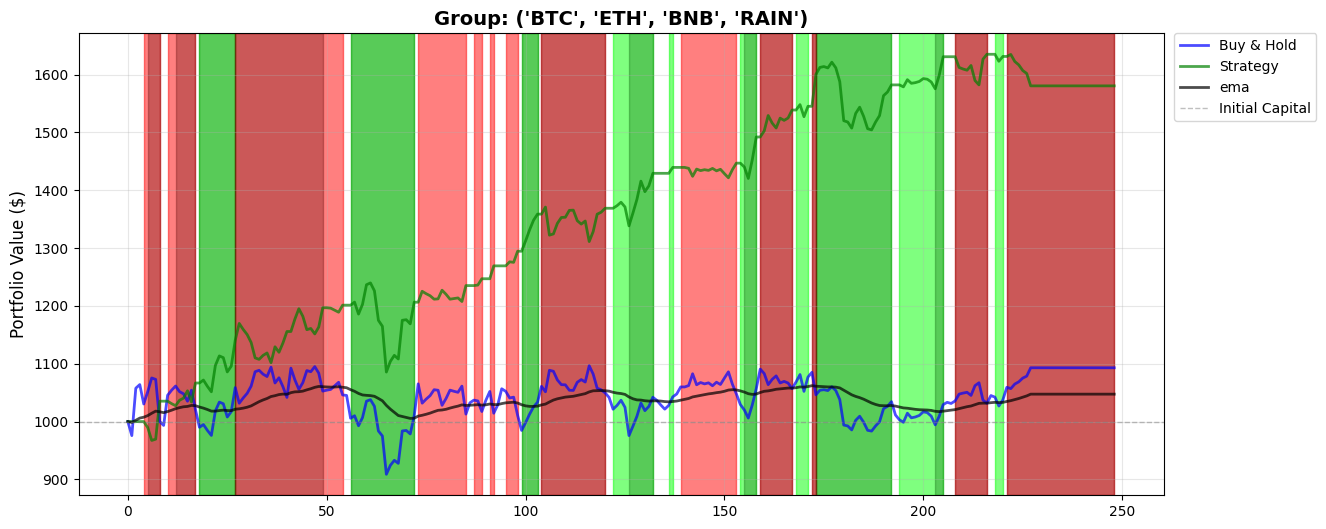

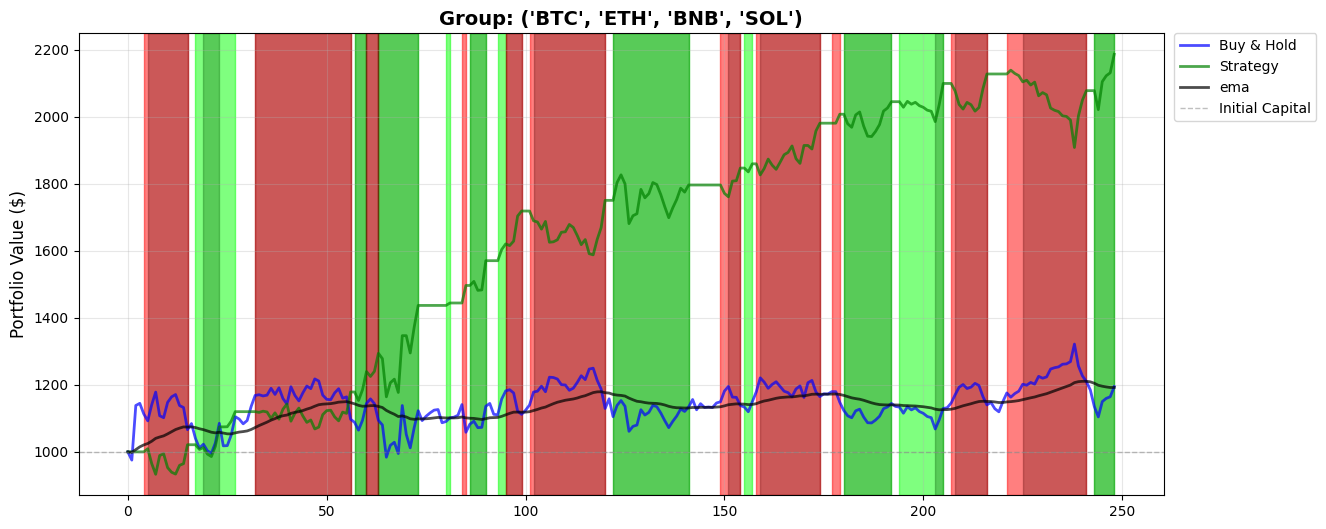

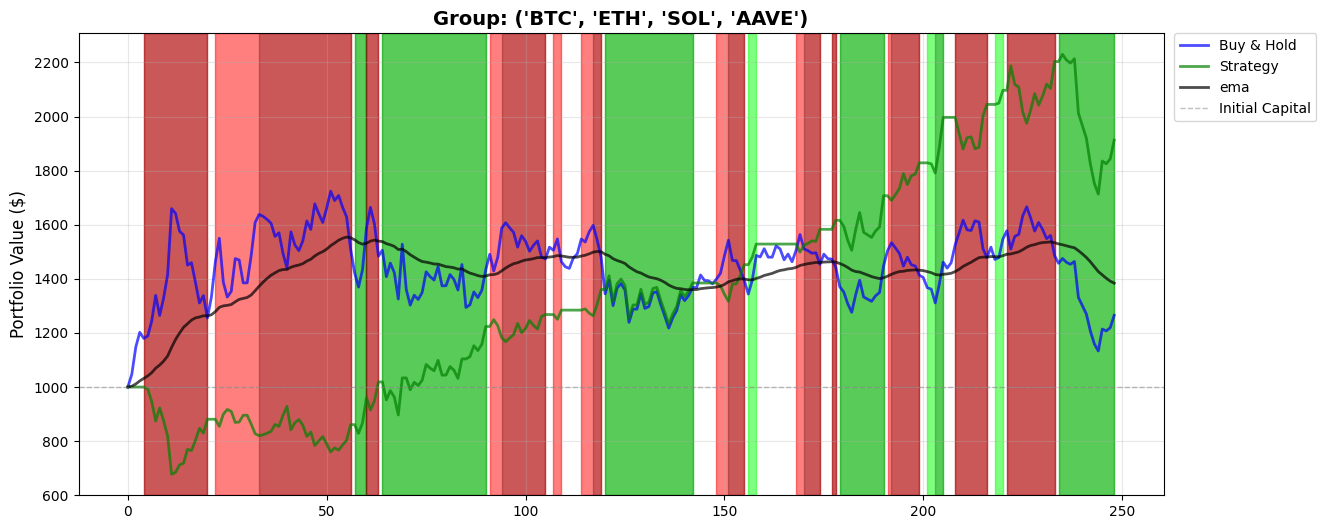

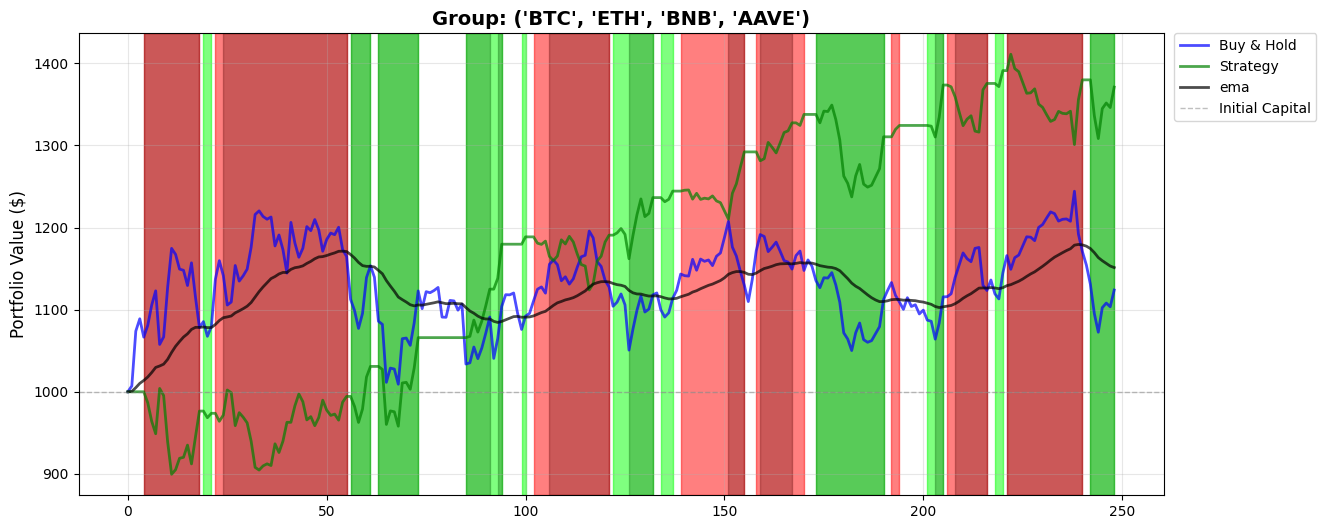

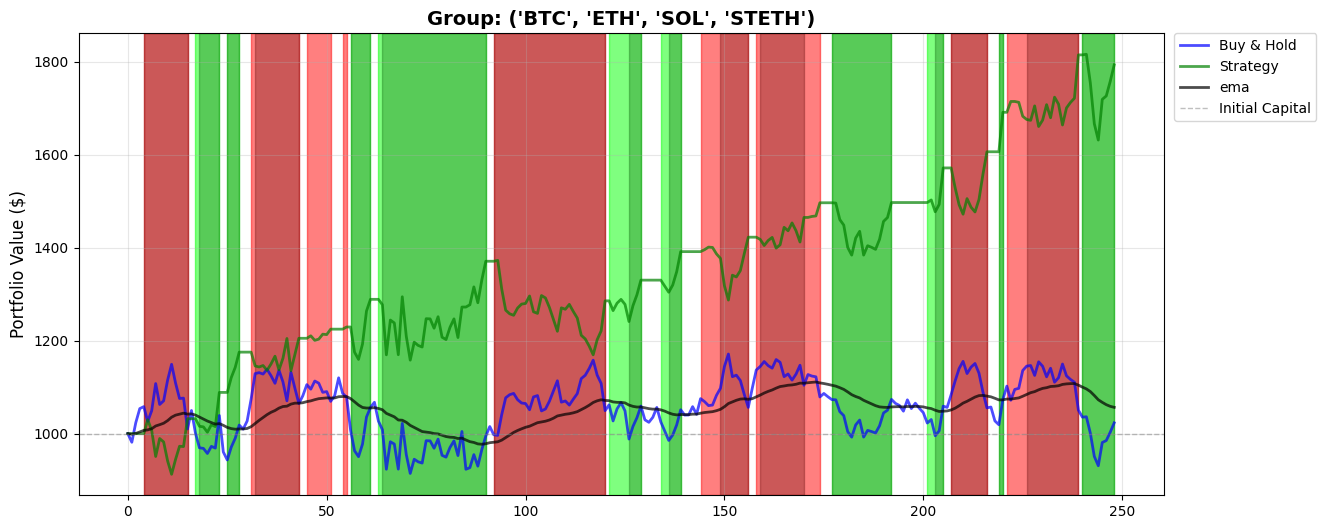

In [3136]:
for result in strategy_results:
    # print(result['spread_df'])
    df = result['spread_df']
    result['spread_df']['short_signal1'] = np.where(df['High'] > df['ema'] + df['std'], 1, 0)
    result['spread_df']['short_signal2'] = np.where(df['High'] > df['ema'] + 2 * df['std'], 1, 0)
    
    result['spread_df']['long_signal1'] = np.where(df['Low'] < df['ema'] - df['std'], 1, 0)
    result['spread_df']['long_signal2'] = np.where(df['Low'] < df['ema'] - 2 * df['std'], 1, 0)
    
    result['spread_df']['above_ema'] = np.where(df['Close'] > df['ema'], 1, 0)
    result['spread_df']['below_ema'] = np.where(df['Close'] < df['ema'], 1, 0)
    
    result['spread_df']['ema_long_crossover'] = result['spread_df']['above_ema'].diff()
    result['spread_df']['ema_short_crossover'] = result['spread_df']['below_ema'].diff()
    
    result['spread_df']['short_crossover1'] = result['spread_df']['short_signal1'].diff()
    result['spread_df']['short_crossover2'] = result['spread_df']['short_signal2'].diff()
    
    result['spread_df']['long_crossover1'] = result['spread_df']['long_signal1'].diff()
    result['spread_df']['long_crossover2'] = result['spread_df']['long_signal2'].diff()
    
    current_position = 0
    positions = np.zeros(len(df))

    for i in range(len(df)):
        if result['spread_df']['short_crossover2'].iloc[i] == 1:
            current_position = -2
        elif result['spread_df']['short_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = -1
        if result['spread_df']['long_crossover2'].iloc[i] == 1:  
            current_position = +2
        elif result['spread_df']['long_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = +1
        elif result['spread_df']['ema_long_crossover'].iloc[i] == 1:  
            if current_position > 0:
                current_position = 0
        elif result['spread_df']['ema_short_crossover'].iloc[i] == 1:  
            if current_position < 0:
                current_position = 0
            
        positions[i] = current_position
        
    result['spread_df']['position'] = positions
    
    result['spread_df']['strategy_return'] = result['spread_df']['position'].shift(1) * result['spread_df']['Return'] / 2
    result['spread_df']['strategy_return'] = result['spread_df']['strategy_return'].fillna(0)
    
    portfolio_values = np.zeros(len(df) + 1)
    portfolio_values[0] = 1000

    for i in range(len(df)):
        portfolio_values[i + 1] = portfolio_values[i] * (1 + result['spread_df']['strategy_return'].iloc[i] / 100)

    result['spread_df']['portfolio'] = portfolio_values[1:]
    
    result['spread_df']['BNH'] = 1000 * (1 + result['spread_df']['Return'] / 100).cumprod()
    result['spread_df'].loc[0, 'BNH'] = 1000
    
    
    
    plt.figure(figsize=(14, 6))
    
    plt.plot(df.index, df['BNH'], label='Buy & Hold', linewidth=2, alpha=0.7, color='blue')
    plt.plot(df.index, df['portfolio'], label='Strategy', linewidth=2, alpha=0.7, color='green')
    # plt.plot(df.index, df['ema'], label='ema', linewidth=2, alpha=0.7, color='orange')
    plt.plot(df.index, df['ema'] * (1000 / df['ema'].iloc[0]), label='ema', linewidth=2, alpha=0.7, color='black')
    
    plt.axhline(y=1000, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
    plt.ylabel('Portfolio Value ($)', fontsize=12)
    plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')
    # plt.legend(loc='best', fontsize=10)
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca() # Get current axes
    long1pos = (df['position'] > 0) | (df['position'].shift(1) > 0)
    long2pos = (df['position'] == 2) | (df['position'].shift(1) == 2)
    short1pos = (df['position'] < 0) | (df['position'].shift(1) < 0)
    short2pos = (df['position'] == -2) | (df['position'].shift(1) == -2)
    plt.fill_between(df.index, 0, 1, where=(long1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0F0')
    plt.fill_between(df.index, 0, 1, where=(short1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#F00')
    plt.fill_between(df.index, 0, 1, where=(long2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#050')
    plt.fill_between(df.index, 0, 1, where=(short2pos), transform=ax.get_xaxis_transform(), alpha=0.3, color='#500')
    
    df = result['spread_df']
    # df['trade_id'] = (np.sign(df['position']) != np.sign(df['position'].shift())).cumsum()
    
    # # 2. Filter for active trades only (remove the '0'/flat periods)
    
    # active_df = df[df['position'] != 0].copy()

    # if not active_df.empty:
    #     # temp_df = active_df.reset_index()
    #     idx_col = temp_df.columns[0]
        
    #     # 3. Aggregate metadata
    #     trades = temp_df.groupby('trade_id').agg(
    #         pos_type=('position', 'first'),
    #         start_idx=(idx_col, 'first'),
    #         end_idx=(idx_col, 'last')
    #     )

    #     running_total_gain = 1
    #     for t_id, trade in trades.iterrows():
    #         # --- LAG FIX ---
    #         start_val = df.loc[trade['start_idx'] + 1, 'portfolio']
    #         try:
    #             end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
    #         except:
    #             end_val = df.loc[trade['end_idx'], 'portfolio']
                
            
    #         # Calculate Return for THIS trade (End / Start)
    #         # This automatically respects the /2 logic because 'portfolio' already 
    #         # grew/shrank by the halved amount.
    #         actual_trade_return = (end_val / start_val - 1) * 100
            
    #         # Calculate Running Total (Total Gain from $1000 start)
    #         running_total_gain = (end_val / 1000 - 1) * 100
            
    #         # Calculate horizontal center for the label
    #         mid_point = (trade['start_idx'] + trade['end_idx']) / 2
            
    #         label1 = f"{actual_trade_return:.2f}%"
    #         label2 = f"{running_total_gain:.2f}%"
            
    #         # 4. Placement
    #         ax.text(mid_point, 0.5, label1, 
    #                 transform=ax.get_xaxis_transform(),
    #                 fontweight='bold',
    #                 ha='center', va='center', 
    #                 fontsize=7, rotation=90,
    #                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
    #         ax.text(mid_point, -0.15, label2, 
    #                 transform=ax.get_xaxis_transform(),
    #                 fontweight='bold',
    #                 ha='center', va='center', 
    #                 fontsize=11, rotation=90,
    #                 bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))

    #         # 5. Background Span
    #         c_map = {1.0: '#0F0', 2.0: '#050', -1.0: '#F00', -2.0: '#500'}
    #         color = c_map.get(trade['pos_type'], 'gray')
            
    #         ax.axvspan(trade['start_idx'] - 0.5, trade['end_idx'] + 0.5, 
    #                 color=color, alpha=0.2, linewidth=0)
    
    
    columns_to_drop = [
        'short_crossover2', 'short_crossover1', 'long_crossover1', 'long_crossover2', 
        'short_signal1', 'short_signal2', 'long_signal1', 'long_signal2', 'above_ema', 'below_ema',
        'ema_long_crossover', 'ema_short_crossover', 
        # 'trade_id'
        ]
    result['spread_df'] = result['spread_df'].drop(columns=columns_to_drop)
        

    plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')

# trades  
x = strategy_results[1]
print(x['group'])
x['spread_df'].tail(20)
# trades

# Lookahead Bias

In [3173]:
def test_strategy(start_date: str = "2025-01-01", end_date: str | None = None):
    start_dt = pd.to_datetime(start_date)
    if end_date is None:    
        end_dt = start_dt + relativedelta(months=3)
        end_date = end_dt.date().strftime('%Y-%m-%d')
    
    deadline_dt = start_dt + relativedelta(months=1)
    deadline = deadline_dt.date().strftime('%Y-%m-%d')
    
    train_start_date = start_dt - relativedelta(months=6)
    train_end_date = start_dt - relativedelta(days=1)
    # print("start train", train_start_date.date())
    
    summary_results = []

    for ticker in TOP_50:
        try:
            # df_full = fetch_from_yfinance(ticker, filename, START_DATE, END_DATE, FETCH_DATA)
            # df_full.index = pd.to_datetime(df_full.index)
            # df = df_full.loc[train_start_date : train_end_date].copy()
            df = filter_ticker(ticker, train_start_date.date().strftime('%Y-%m-%d'), train_end_date.date().strftime('%Y-%m-%d'))

            res = adf_test(ticker, df)
            res['hurst'] = hurst_exponent(df['Close'])
            res['half_life'] = half_life(df['Close'])
            res['df'] = df
            summary_results.append(res)

        except Exception as e:
            print(f"Failed {ticker}: {e}")

    summary_df = pd.DataFrame(summary_results)
    stationary_df = summary_df[summary_df['p-value'] <= 0.05].copy()
    stationary_df = stationary_df.sort_values(by='p-value')
    found_combinations = []
    non_stationary_tickers = summary_df[summary_df['p-value'] > 0.05]['Ticker'].tolist()
    
    dfs = {item['Ticker']: item['df'] for item in summary_results}
    # --------------------------------------------------------------------------
    for r in [4, 5]:
        if len(found_combinations) >= 10: break
        
        potential_groups = list(itertools.combinations(non_stationary_tickers[:20], r)) 

        for group in potential_groups:
            if len(found_combinations) >= 10: break
            
            combined_data = pd.concat([dfs[t]['Close'] for t in group], axis=1).dropna()
            
            res = coint_johansen(combined_data, det_order=0, k_ar_diff=1)
            
            if res.lr1[0] > res.cvt[0, 1]: 
                weights = res.evec[:, 0] 
                found_combinations.append({
                    'group': group,
                    'weights': weights,
                    'johansen_stat': res.lr1[0]
                })
                
    # -------------------------------------------------------------------------------------
    results_with_hl = []
    for item in found_combinations:
        group = item['group']
        weights = item['weights']
        
        spread_series = pd.Series(0, index=dfs[group[0]].index)
        for i, ticker in enumerate(group):
            spread_series += dfs[ticker]['Close'] * weights[i]
        
        hl = half_life(spread_series)
        
        results_with_hl.append({
            'group': group,
            'half_life': hl,
            'spread_series': spread_series,
            'weights': weights
        })

    # ------------------------------------------------------------------------
    positive_spread_results = [
        res for res in results_with_hl 
        if (res['spread_series'] > 0).all()
    ]
    comb = sorted(positive_spread_results, key=lambda x: x['half_life'])[0]
    
    group = comb['group']
    weights = comb['weights']
    hl = comb['half_life']
    dfs = {ticker: filter_ticker(ticker, start_date, end_date) for ticker in group}
    # df_full = fetch_from_yfinance(ticker, filename, START_DATE, END_DATE, FETCH_DATA)
    # df_full.index = pd.to_datetime(df_full.index)
    # dfs[ticker] = df_full.loc[start_date : end_date].copy()
    # dfs[ticker] = filter_ticker(ticker, start_date, end_date)
    # print("dfs", group)
    
    spread_df = pd.DataFrame(index=dfs[group[0]].index)
    spread_df['Close'] = sum(dfs[ticker]['Close'] * weights[i] for i, ticker in enumerate(group))
    spread_df['Open']  = sum(dfs[ticker]['Open'] * weights[i] for i, ticker in enumerate(group))
    
    spread_df['Return'] = spread_df['Close'].pct_change() * 100
    
    s_high, s_low = 0, 0
    for i, ticker in enumerate(group):
        if weights[i] >= 0:
            s_high += dfs[ticker]['High'] * weights[i]
            s_low  += dfs[ticker]['Low'] * weights[i]
        else:
            s_high += dfs[ticker]['Low'] * weights[i]
            s_low  += dfs[ticker]['High'] * weights[i]
    spread_df['High'], spread_df['Low'] = s_high, s_low
    
    lb, ema, std = calculate_strategy_params(spread_df, hl)
    
    spread_df['std'] = std
    spread_df['ema'] = ema
    spread_df['Date'] = dfs[ticker]['Date']
    
    print(f"\nGroup: {'-'.join(group)}")
    print(f"Half-life: {hl:.2f} days")
    print(f"Calculated Lookback: {lb} days")
    print(f"Latest EMA (of Range): {ema.iloc[-1]:.4f}")
    print(f"Latest STD: {std.iloc[-1]:.4f}")
    
    # ------------------------------------------------------
    
    result = {
        'group': group,
        'spread_df': spread_df,
        'ema_range': ema,
        'std_spread': std,
        'lookback': lb
    }
    
    df = result['spread_df']
    # print(df)
    x = 0.01
    result['spread_df']['short_signal1'] = np.where((df['High'] > df['ema'] + df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    result['spread_df']['short_signal2'] = np.where((df['High'] > df['ema'] + 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    result['spread_df']['long_signal1'] = np.where((df['Low'] < df['ema'] - df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    result['spread_df']['long_signal2'] = np.where((df['Low'] < df['ema'] - 2 * df['std']) & (df['std'] > df['ema'] * x), 1, 0)
    
    result['spread_df']['above_ema'] = np.where(df['Close'] > df['ema'], 1, 0)
    result['spread_df']['below_ema'] = np.where(df['Close'] < df['ema'], 1, 0)
    
    result['spread_df']['ema_long_crossover'] = result['spread_df']['above_ema'].diff()
    result['spread_df']['ema_short_crossover'] = result['spread_df']['below_ema'].diff()
    
    result['spread_df']['short_crossover1'] = result['spread_df']['short_signal1'].diff()
    result['spread_df']['short_crossover2'] = result['spread_df']['short_signal2'].diff()
    
    result['spread_df']['long_crossover1'] = result['spread_df']['long_signal1'].diff()
    result['spread_df']['long_crossover2'] = result['spread_df']['long_signal2'].diff()
    
    current_position = 0
    positions = np.zeros(len(df))

    for i in range(len(df)):
        
        if result['spread_df']['below_ema'].iloc[i] == 1 and current_position < 0:
            current_position = 0
        elif result['spread_df']['above_ema'].iloc[i] == 1 and current_position > 0:
            current_position = 0
        elif result['spread_df']['short_crossover2'].iloc[i] == 1 and result['spread_df']['above_ema'].iloc[i] == 1:
            current_position = -2
        elif result['spread_df']['short_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = -1
        elif result['spread_df']['long_crossover2'].iloc[i] == 1 and result['spread_df']['below_ema'].iloc[i] == 1:  
            current_position = +2
        elif result['spread_df']['long_crossover1'].iloc[i] == 1 and current_position == 0:  
            current_position = +1
        elif result['spread_df']['ema_long_crossover'].iloc[i] == 1 or result['spread_df']['ema_short_crossover'].iloc[i] == 1:
            current_position = 0
            
        positions[i] = current_position
        
    result['spread_df']['position'] = positions
    
    closed_after_deadline = result['spread_df'][
        (result['spread_df']['Date'] >= deadline_dt) & 
        (result['spread_df']['position'] == 0)
    ]
    
    if not closed_after_deadline.empty:
        first_close_row = closed_after_deadline.iloc[0]
        new_start_date = first_close_row['Date']
    else:
        new_start_date = result['spread_df']['Date'].iloc[-1]
        
    # print("new_start_date", new_start_date.date().strftime('%Y-%m-%d'))
    
    mask = (result['spread_df']['Date'] <= new_start_date)
    result['spread_df'] = result['spread_df'].loc[mask].copy()
    
    df = result['spread_df']
    
    result['spread_df']['strategy_return'] = result['spread_df']['position'].shift(1) * result['spread_df']['Return'] / 2
    result['spread_df']['strategy_return'] = result['spread_df']['strategy_return'].fillna(0)
    
    portfolio_values = np.zeros(len(df) + 1)
    portfolio_values[0] = 1000

    for i in range(len(df)):
        portfolio_values[i + 1] = portfolio_values[i] * (1 + result['spread_df']['strategy_return'].iloc[i] / 100)

    result['spread_df']['portfolio'] = portfolio_values[1:]
    
    result['spread_df']['BNH'] = 1000 * (1 + result['spread_df']['Return'] / 100).cumprod()
    result['spread_df'].loc[0, 'BNH'] = 1000
    
    # -------------------------------------------------------------
    plt.figure(figsize=(14, 6))
    
    plt.plot(df.index, df['BNH'], label='Buy & Hold', linewidth=2, alpha=0.7, color='blue')
    plt.plot(df.index, df['portfolio'], label='Strategy', linewidth=2, alpha=0.7, color='red')
    plt.plot(df.index, df['ema'] * (1000 / df['ema'].iloc[0]), label='ema', linewidth=2, alpha=0.7, color='black')
    
    plt.axhline(y=1000, color='gray', linestyle='--', linewidth=1, alpha=0.5, label='Initial Capital')
    plt.ylabel('Portfolio Value ($)', fontsize=12)
    plt.title(f'Group: {result["group"]}', fontsize=14, fontweight='bold')
    # plt.legend(loc='best', fontsize=10)
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    plt.grid(True, alpha=0.3)
    
    ax = plt.gca() # Get current axes
    long1pos = (df['position'] == 1) | (df['position'].shift(1) == 1)
    long2pos = (df['position'] == 2) | (df['position'].shift(1) == 2)
    short1pos = (df['position'] == -1) | (df['position'].shift(1) == -1)
    short2pos = (df['position'] == -2) | (df['position'].shift(1) == -2)
    plt.fill_between(df.index, 0, 1, where=(long1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0F0')
    plt.fill_between(df.index, 0, 1, where=(short1pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#F00')
    plt.fill_between(df.index, 0, 1, where=(long2pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#0A0')
    plt.fill_between(df.index, 0, 1, where=(short2pos), transform=ax.get_xaxis_transform(), alpha=0.5, color='#A00')
    
    df = result['spread_df']
    df['trade_id'] = (np.sign(df['position']) != np.sign(df['position'].shift())).cumsum()
    
    
    active_df = df[df['position'] != 0].copy()

    if not active_df.empty:
        temp_df = active_df.reset_index()
        idx_col = temp_df.columns[0]
        
        # 3. Aggregate metadata
        trades = temp_df.groupby('trade_id').agg(
            pos_type=('position', 'first'),
            start_idx=(idx_col, 'first'),
            end_idx=(idx_col, 'last')
        )

        running_total_gain = 1
        
        for t_id, trade in trades.iterrows():
            # --- LAG FIX ---
            start_val = df.loc[trade['start_idx'] + 1, 'portfolio']
            try:
                end_val = df.loc[trade['end_idx'] + 1, 'portfolio']
            except:
                end_val = df.loc[trade['end_idx'], 'portfolio']

            actual_trade_return = (end_val / start_val - 1) * 100
            
            # Calculate Running Total (Total Gain from $1000 start)
            running_total_gain = (end_val / 1000 - 1) * 100
            
            # Calculate horizontal center for the label
            mid_point = (trade['start_idx'] + trade['end_idx']) / 2
            
            label1 = f"{actual_trade_return:.2f}%"
            label2 = f"{running_total_gain:.2f}%"
            
            # 4. Placement
            ax.text(mid_point, 0.5, label1, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=7, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
            
            ax.text(mid_point, 0, label2, 
                    transform=ax.get_xaxis_transform(),
                    fontweight='bold',
                    ha='center', va='center', 
                    fontsize=11, rotation=90,
                    bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', boxstyle='round,pad=0.2'))
    
    
    columns_to_drop = [
        # 'short_crossover2', 'short_crossover1', 'long_crossover1', 'long_crossover2', 
        'short_signal1', 'short_signal2', 'long_signal1', 'long_signal2', 'above_ema', 'below_ema',
        'ema_long_crossover', 'ema_short_crossover', 
        'trade_id'
        ]
    
    result['spread_df'] = result['spread_df'].drop(columns=columns_to_drop)
        

    plt.title(f'Group: {result["group"]} / {start_date} - {new_start_date.date().strftime("%Y-%m-%d")}', fontsize=14, fontweight='bold')
    plt.show()

    return result, new_start_date

Failed XRP: max_lag must be > min_lag
Failed RAIN: max_lag must be > min_lag
Failed ASTER: max_lag must be > min_lag

Group: BTC-ETH-SOL-SHIB
Half-life: 3.64 days
Calculated Lookback: 32 days
Latest EMA (of Range): 10.5918
Latest STD: 0.5986


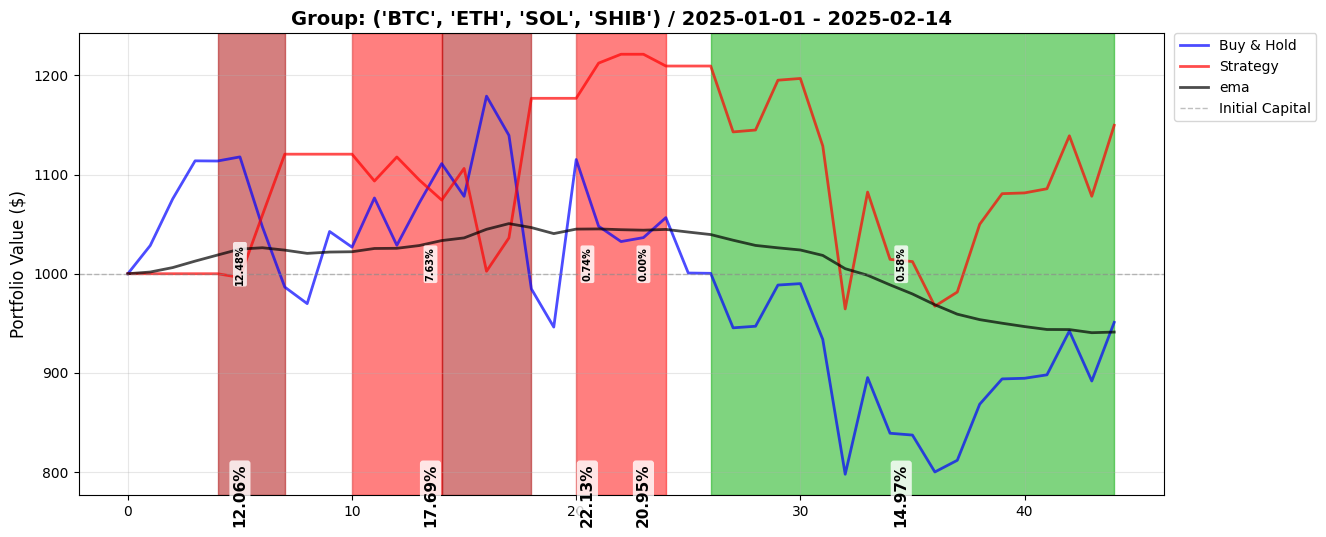

    Close  Open  Return  High   Low  std   ema       Date  short_crossover1  \
0   11.84 11.20     NaN 11.96 11.03  NaN 11.84 2025-01-01               NaN   
1   12.17 11.69    2.85 12.46 11.37  NaN 11.86 2025-01-02              0.00   
2   12.73 12.08    4.57 13.53 11.78  NaN 11.91 2025-01-03              0.00   
3   13.19 12.79    3.57 14.16 12.42  NaN 11.99 2025-01-04              0.00   
4   13.18 13.18   -0.02 13.61 12.83 0.60 12.06 2025-01-05              1.00   
5   13.23 13.27    0.37 14.12 12.34 0.59 12.13 2025-01-06              0.00   
6   12.40 13.52   -6.30 14.03 12.06 0.56 12.15 2025-01-07              0.00   
7   11.68 12.32   -5.81 12.47 10.97 0.62 12.12 2025-01-08             -1.00   
8   11.48 11.73   -1.69 12.57 11.25 0.69 12.08 2025-01-09              0.00   
9   12.34 11.72    7.50 12.59 11.46 0.65 12.10 2025-01-10              0.00   
10  12.16 12.31   -1.51 13.17 11.40 0.62 12.10 2025-01-11              1.00   
11  12.74 12.67    4.83 12.99 11.81 0.60 12.14 2025-

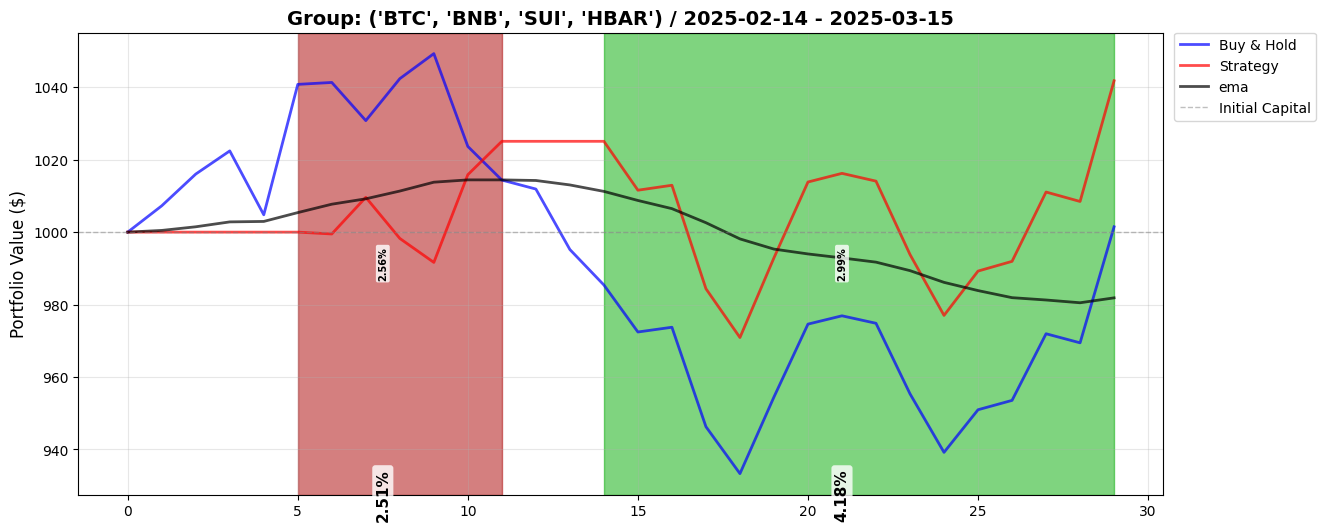

    Close  Open  Return  High   Low  std   ema       Date  short_crossover1  \
0   66.55 67.94     NaN 68.98 65.98  NaN 66.55 2025-02-14               NaN   
1   67.03 66.44    0.73 67.78 65.88  NaN 66.58 2025-02-15              0.00   
2   67.62 67.12    0.87 68.65 66.12  NaN 66.65 2025-02-16              0.00   
3   68.04 67.67    0.63 68.97 66.58  NaN 66.74 2025-02-17              0.00   
4   66.87 68.09   -1.73 68.98 65.63 0.60 66.75 2025-02-18              0.00   
5   69.27 68.30    3.59 70.42 66.84 0.99 66.91 2025-02-19              1.00   
6   69.30 69.11    0.05 70.11 68.37 1.12 67.06 2025-02-20              0.00   
7   68.60 69.24   -1.01 70.48 67.43 1.07 67.16 2025-02-21              0.00   
8   69.37 68.53    1.12 70.97 67.76 1.12 67.31 2025-02-22              0.00   
9   69.83 69.76    0.66 70.97 68.32 1.19 67.47 2025-02-23              0.00   
10  68.13 70.03   -2.44 70.71 66.44 1.13 67.51 2025-02-24              0.00   
11  67.51 68.16   -0.91 69.80 65.45 1.10 67.51 2025-

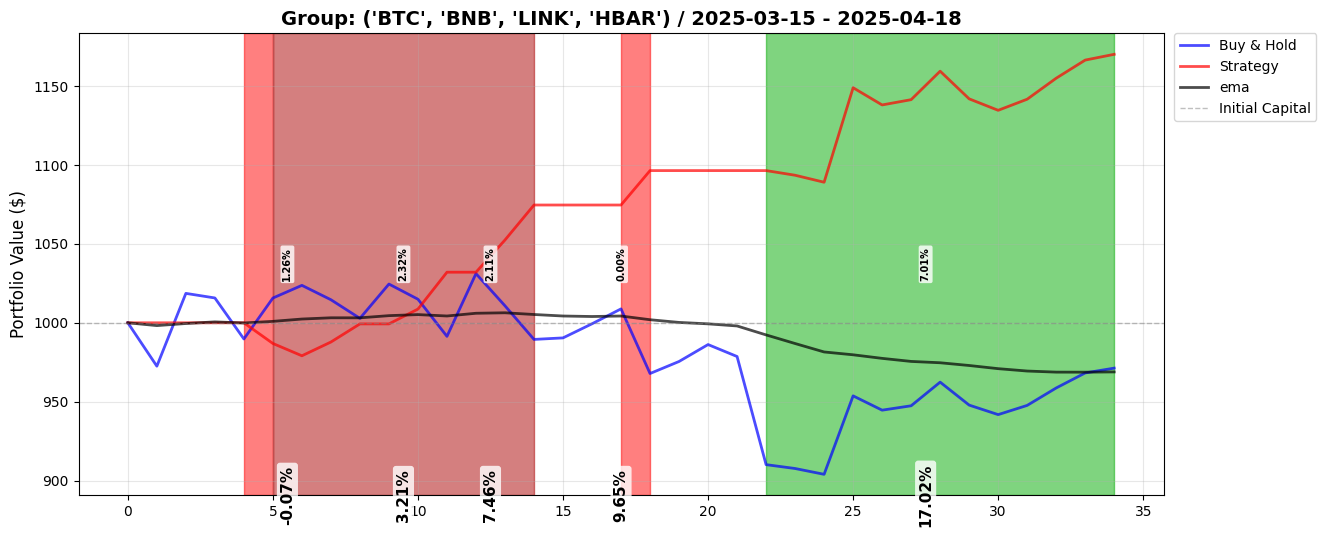

    Close  Open  Return  High   Low  std   ema       Date  short_crossover1  \
0   26.70 25.14     NaN 26.93 24.74  NaN 26.70 2025-03-15               NaN   
1   25.97 26.74   -2.75 27.13 25.26  NaN 26.65 2025-03-16              0.00   
2   27.20 26.07    4.74 28.30 25.53  NaN 26.69 2025-03-17              0.00   
3   27.12 27.28   -0.28 28.36 26.75  NaN 26.72 2025-03-18              0.00   
4   26.43 26.85   -2.56 27.38 25.45 0.51 26.70 2025-03-19              1.00   
5   27.12 26.53    2.62 27.92 25.85 0.49 26.72 2025-03-20              0.00   
6   27.33 27.16    0.79 27.77 26.72 0.50 26.76 2025-03-21              0.00   
7   27.09 27.45   -0.89 27.73 26.73 0.47 26.78 2025-03-22              0.00   
8   26.78 26.94   -1.16 27.29 26.43 0.44 26.78 2025-03-23              0.00   
9   27.36 26.87    2.17 27.78 26.28 0.44 26.82 2025-03-24              0.00   
10  27.10 27.47   -0.94 28.01 26.71 0.42 26.84 2025-03-25              0.00   
11  26.47 27.14   -2.32 27.48 26.11 0.43 26.82 2025-

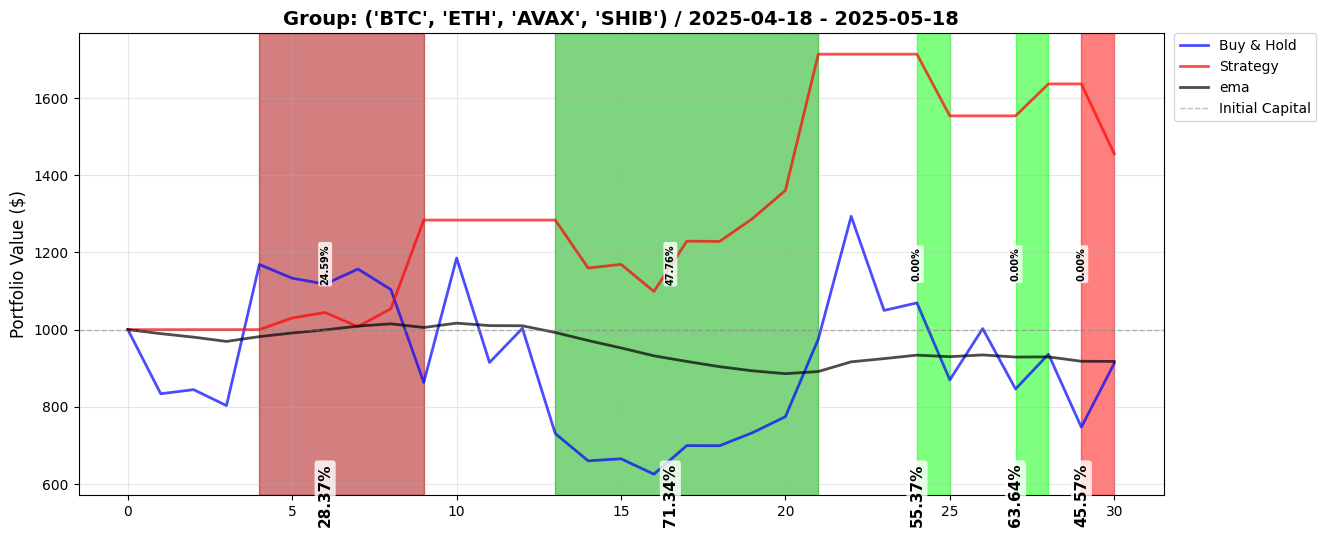

    Close  Open  Return  High  Low  std  ema       Date  short_crossover1  \
0    2.37  2.30     NaN  2.47 2.17  NaN 2.37 2025-04-18               NaN   
1    1.97  2.32  -16.61  2.36 1.76  NaN 2.34 2025-04-19              0.00   
2    2.00  1.84    1.28  2.93 1.74  NaN 2.32 2025-04-20              0.00   
3    1.90  2.04   -4.89  2.86 1.55  NaN 2.29 2025-04-21              0.00   
4    2.77  1.91   45.48  3.66 1.06 0.36 2.32 2025-04-22              1.00   
5    2.68  2.77   -3.03  2.90 1.63 0.38 2.35 2025-04-23              0.00   
6    2.65  2.66   -1.34  2.89 1.75 0.37 2.36 2025-04-24              0.00   
7    2.74  2.71    3.48  2.94 2.50 0.37 2.39 2025-04-25              0.00   
8    2.61  2.68   -4.60  3.66 2.39 0.36 2.40 2025-04-26              0.00   
9    2.04  2.63  -21.78  2.88 1.67 0.36 2.38 2025-04-27              0.00   
10   2.80  2.06   37.28  3.09 1.80 0.36 2.41 2025-04-28              0.00   
11   2.17  2.88  -22.80  3.09 1.89 0.35 2.39 2025-04-29              0.00   

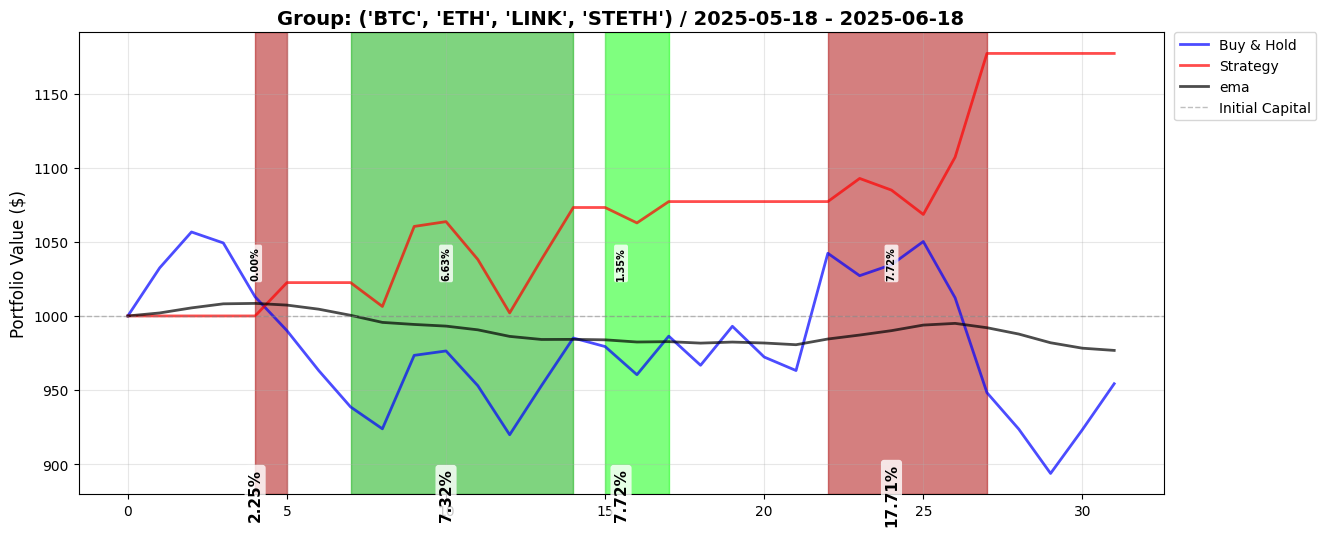

    Close  Open  Return  High   Low  std   ema       Date  short_crossover1  \
0   28.86 28.14     NaN 29.93 26.88  NaN 28.86 2025-05-18               NaN   
1   29.80 28.52    3.24 30.18 27.63  NaN 28.92 2025-05-19              0.00   
2   30.50 29.45    2.35 31.51 28.24  NaN 29.02 2025-05-20              0.00   
3   30.28 30.74   -0.70 31.45 28.96  NaN 29.10 2025-05-21              0.00   
4   29.23 29.55   -3.47 30.69 28.39 0.69 29.11 2025-05-22              1.00   
5   28.58 29.22   -2.25 30.03 27.07 0.78 29.07 2025-05-23              0.00   
6   27.80 28.12   -2.72 28.99 27.35 0.97 28.99 2025-05-24             -1.00   
7   27.09 28.16   -2.55 28.61 26.23 1.19 28.87 2025-05-25              0.00   
8   26.66 26.84   -1.57 27.52 25.18 1.36 28.74 2025-05-26              0.00   
9   28.09 26.79    5.36 28.61 26.17 1.30 28.70 2025-05-27              0.00   
10  28.18 27.81    0.30 28.58 27.28 1.24 28.66 2025-05-28              0.00   
11  27.50 27.79   -2.40 28.57 26.89 1.23 28.59 2025-

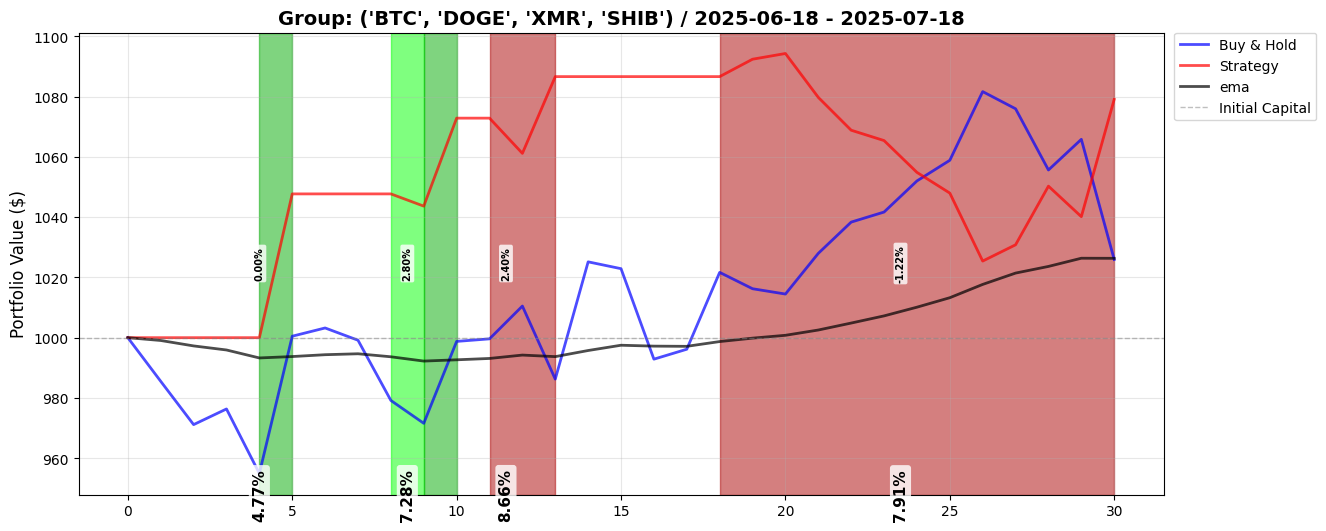

    Close  Open  Return  High   Low  std   ema       Date  short_crossover1  \
0   52.08 52.69     NaN 54.57 50.60  NaN 52.08 2025-06-18               NaN   
1   51.33 52.19   -1.45 53.33 49.10  NaN 52.04 2025-06-19              0.00   
2   50.58 51.24   -1.46 53.07 49.10  NaN 51.94 2025-06-20              0.00   
3   50.85 50.67    0.53 52.22 49.98  NaN 51.87 2025-06-21              0.00   
4   49.74 50.95   -2.19 52.22 47.06 0.87 51.73 2025-06-22              0.00   
5   52.11 49.71    4.77 52.94 48.37 0.92 51.76 2025-06-23              1.00   
6   52.25 52.07    0.27 53.18 51.11 0.94 51.79 2025-06-24              0.00   
7   52.04 52.30   -0.41 53.47 51.68 0.91 51.81 2025-06-25              0.00   
8   51.00 51.99   -2.00 53.39 50.21 0.86 51.75 2025-06-26              0.00   
9   50.60 51.10   -0.77 51.43 49.78 0.85 51.68 2025-06-27             -1.00   
10  52.02 50.59    2.80 52.95 49.86 0.83 51.70 2025-06-28              1.00   
11  52.06 51.98    0.08 53.72 49.89 0.82 51.73 2025-

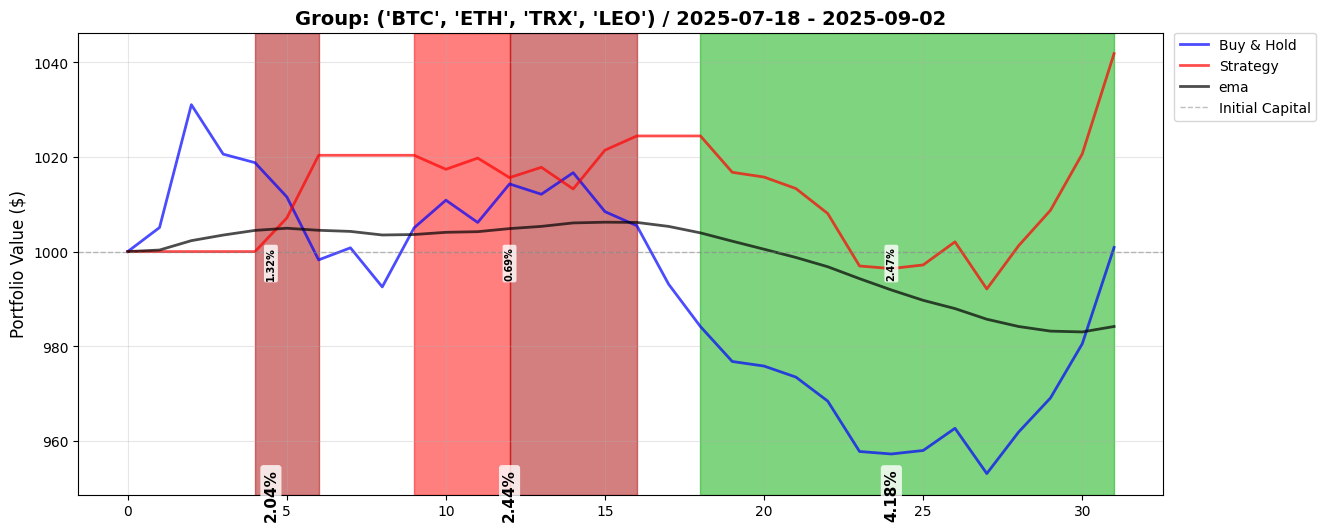

    Close  Open  Return  High   Low  std   ema       Date  short_crossover1  \
0   71.31 71.20     NaN 71.73 70.00  NaN 71.31 2025-07-18               NaN   
1   71.67 70.56    0.51 72.23 69.29  NaN 71.33 2025-07-21              0.00   
2   73.52 72.31    2.58 73.91 71.60  NaN 71.47 2025-07-22              0.00   
3   72.78 73.18   -1.01 73.70 71.57  NaN 71.56 2025-07-23              0.00   
4   72.65 73.17   -0.18 74.00 71.75 0.89 71.63 2025-07-24              1.00   
5   72.13 72.54   -0.71 73.48 69.89 0.80 71.66 2025-07-25              0.00   
6   71.18 72.31   -1.32 72.76 70.72 0.86 71.63 2025-07-28              0.00   
7   71.36 71.80    0.26 72.38 70.72 0.84 71.61 2025-07-29             -1.00   
8   70.78 71.26   -0.83 72.00 70.00 0.90 71.56 2025-07-30              0.00   
9   71.67 71.41    1.26 72.85 70.37 0.85 71.56 2025-07-31              1.00   
10  72.08 71.88    0.58 72.62 70.69 0.81 71.60 2025-08-01              0.00   
11  71.75 71.96   -0.47 73.05 70.79 0.77 71.61 2025-

C:\Users\afiro\AppData\Local\Temp\ipykernel_10792\2259758511.py:100: FutureWarning:

The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.



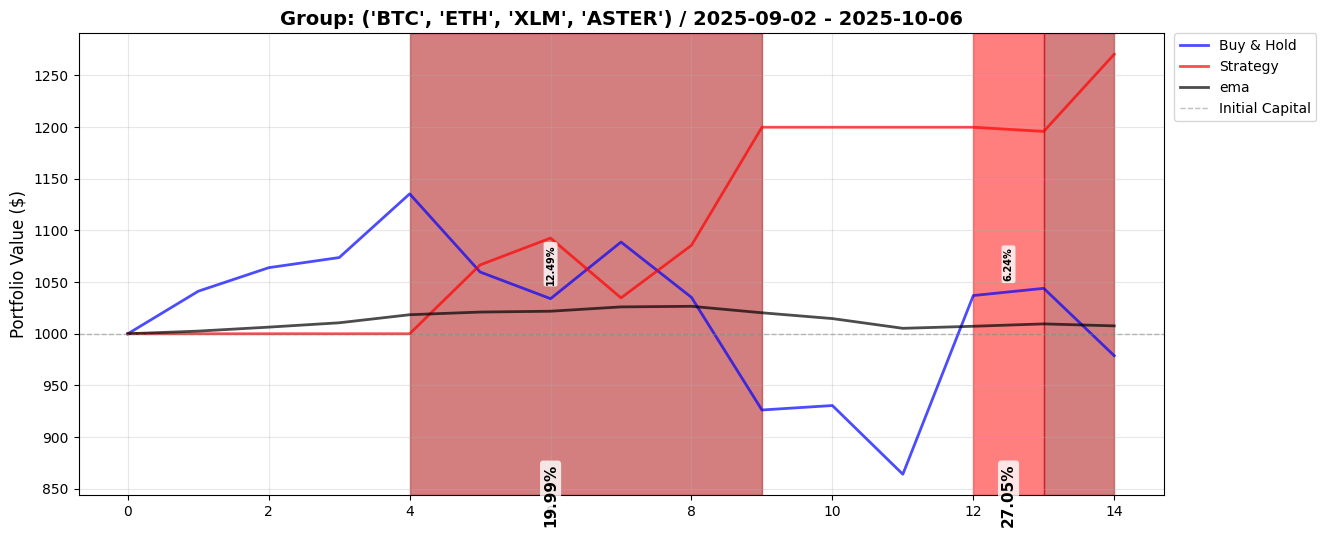

    Close  Open  Return  High  Low  std  ema       Date  short_crossover1  \
0    5.77  5.81     NaN  6.60 5.09  NaN 5.77 2025-09-02               NaN   
1    6.01  5.73    4.12  6.34 5.43  NaN 5.78 2025-09-03              0.00   
2    6.14  5.76    2.19  6.50 5.32  NaN 5.81 2025-09-04              0.00   
3    6.19  6.62    0.92  7.14 5.23  NaN 5.83 2025-09-05              0.00   
4    6.55  6.34    5.74  6.91 6.11 0.29 5.87 2025-09-06              1.00   
5    6.11  6.66   -6.66  6.81 5.71 0.26 5.89 2025-09-07              0.00   
6    5.96  6.59   -2.44  7.03 5.39 0.24 5.89 2025-09-08              0.00   
7    6.28  5.84    5.30  6.44 5.40 0.23 5.92 2025-09-09              0.00   
8    5.97  6.23   -4.92  6.82 5.34 0.22 5.92 2025-09-10              0.00   
9    5.34  5.74  -10.53  5.99 4.98 0.32 5.89 2025-09-11             -1.00   
10   5.37  5.36    0.47  6.13 4.76 0.36 5.85 2025-09-12              0.00   
11   4.98  5.18   -7.15  5.53 4.34 0.45 5.80 2025-09-13              0.00   

C:\Users\afiro\AppData\Local\Temp\ipykernel_10792\3329346929.py:24: RankWarning:

Polyfit may be poorly conditioned



Failed CBBTC: max_lag must be > min_lag

Group: ETH-BNB-ZEC-DAI
Half-life: 0.28 days
Calculated Lookback: 30 days
Latest EMA (of Range): 12516.1662
Latest STD: 10.9724


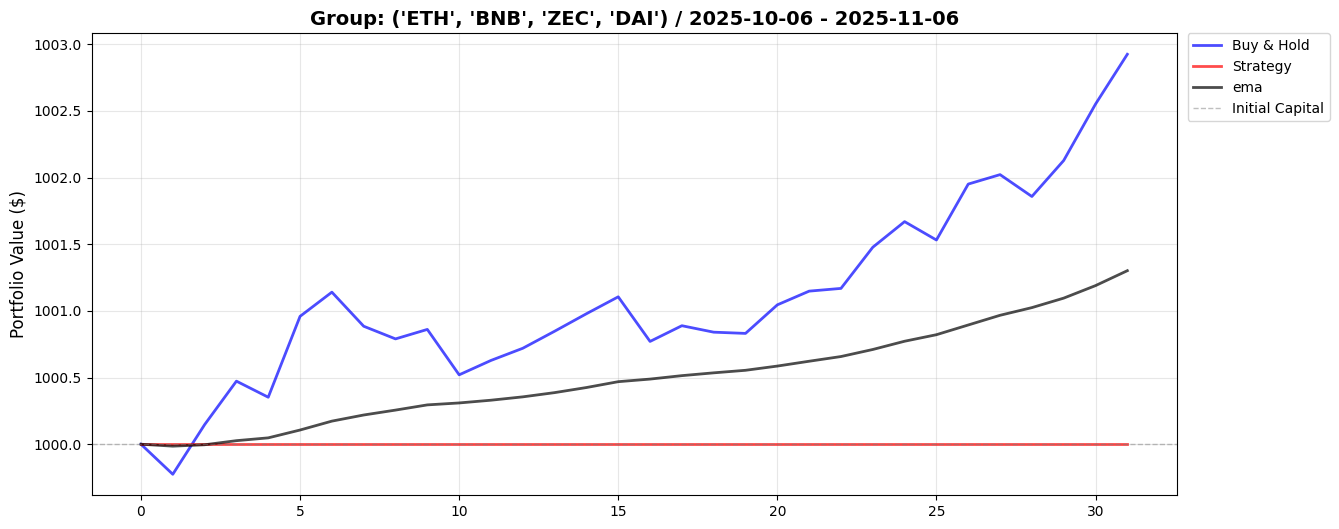

      Close     Open  Return     High      Low  std      ema       Date  \
0  12493.20 12494.55     NaN 12496.78 12488.48  NaN 12493.20 2025-10-06   
1  12490.38 12493.16   -0.02 12495.93 12485.99  NaN 12493.02 2025-10-07   
2  12495.03 12490.30    0.04 12500.27 12489.25  NaN 12493.15 2025-10-08   
3  12499.11 12495.10    0.03 12502.15 12489.54  NaN 12493.53 2025-10-09   
4  12497.60 12499.01   -0.01 12532.68 12484.81 3.47 12493.79 2025-10-10   
5  12505.18 12497.65    0.06 12512.86 12487.17 5.17 12494.53 2025-10-11   
6  12507.45 12505.17    0.02 12513.77 12499.11 6.21 12495.36 2025-10-12   
7  12504.25 12507.46   -0.03 12511.06 12498.85 6.13 12495.94 2025-10-13   
8  12503.07 12504.26   -0.01 12509.99 12496.60 5.89 12496.40 2025-10-14   
9  12503.96 12503.04    0.01 12512.08 12497.83 5.73 12496.88 2025-10-15   
10 12499.70 12503.92   -0.03 12512.29 12496.28 5.44 12497.06 2025-10-16   
11 12501.05 12499.70    0.01 12509.52 12495.30 5.19 12497.32 2025-10-17   
12 12502.19 12501.05    0

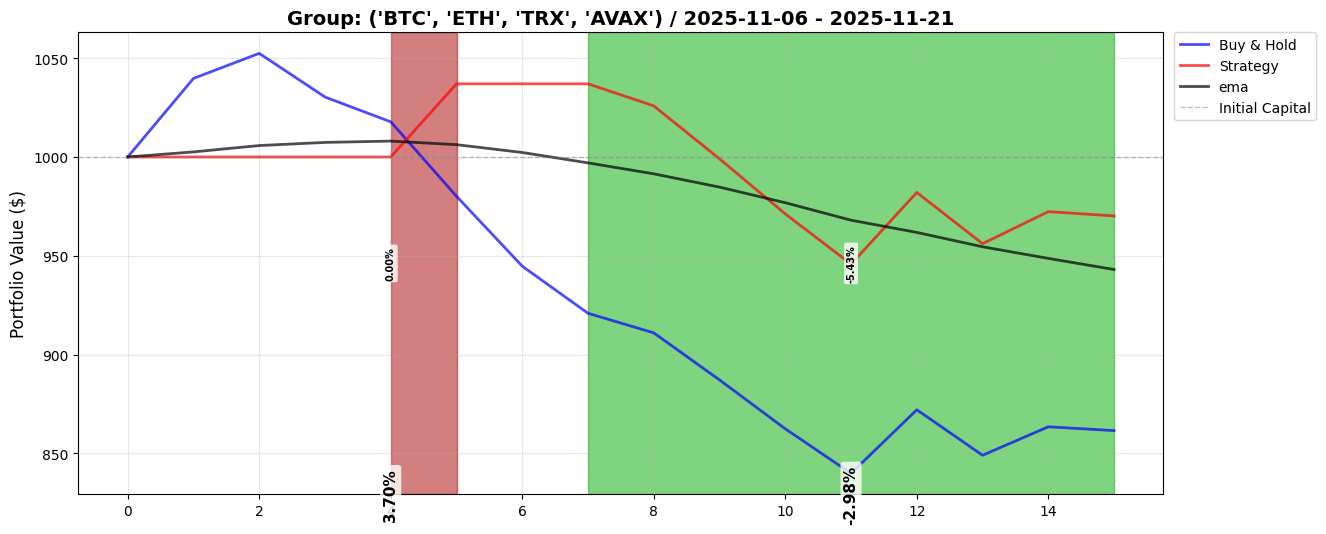

    Close  Open  Return  High   Low  std   ema       Date  short_crossover1  \
0   35.43 36.19     NaN 36.50 34.83  NaN 35.43 2025-11-06               NaN   
1   36.84 35.30    3.98 37.48 34.60  NaN 35.52 2025-11-07              0.00   
2   37.29 37.44    1.22 37.93 36.56  NaN 35.64 2025-11-08              0.00   
3   36.51 36.81   -2.10 37.25 35.88  NaN 35.69 2025-11-09              0.00   
4   36.06 37.05   -1.22 37.64 35.37 0.72 35.72 2025-11-10              1.00   
5   34.73 36.35   -3.70 37.38 34.18 0.94 35.65 2025-11-11              0.00   
6   33.47 33.96   -3.61 35.08 33.16 1.33 35.51 2025-11-12             -1.00   
7   32.63 33.42   -2.52 34.79 31.82 1.65 35.33 2025-11-13              0.00   
8   32.28 32.52   -1.08 33.29 31.42 1.86 35.13 2025-11-14              0.00   
9   31.44 31.82   -2.61 32.78 30.71 2.09 34.89 2025-11-15              0.00   
10  30.56 32.00   -2.79 32.71 29.76 2.34 34.61 2025-11-16              0.00   
11  29.76 29.81   -2.61 30.80 28.62 2.58 34.30 2025-

In [3174]:
results = []
starting_date = datetime(2025, 1, 1)
counter = 11
while starting_date < datetime(2025, 11, 20) and counter >= 0:
    res, new_start = test_strategy(starting_date.strftime('%Y-%m-%d'))
    results.append(res)
    starting_date = pd.to_datetime(new_start)
    print(res['spread_df'])
    counter -= 1
    # print(f"new start after {datetime(2025, 1 + i, 1).date().strftime('%Y-%m-%d')} = {new_start}")

In [3175]:
results[5]['spread_df']

,Close,Open,Return,High,Low,std,ema,Date,short_crossover1,short_crossover2,long_crossover1,long_crossover2,position,strategy_return,portfolio,BNH
0,52.08,52.69,NaN,54.57,50.60,NaN,52.08,2025-06-18,NaN,NaN,NaN,NaN,0.00,0.00,1000.00,1000.00
1,51.33,52.19,-1.45,53.33,49.10,NaN,52.04,2025-06-19,0.00,0.00,0.00,0.00,0.00,-0.00,1000.00,985.52
2,50.58,51.24,-1.46,53.07,49.10,NaN,51.94,2025-06-20,0.00,0.00,0.00,0.00,0.00,-0.00,1000.00,971.15
3,50.85,50.67,0.53,52.22,49.98,NaN,51.87,2025-06-21,0.00,0.00,0.00,0.00,0.00,0.00,1000.00,976.35
4,49.74,50.95,-2.19,52.22,47.06,0.87,51.73,2025-06-22,0.00,0.00,1.00,1.00,2.00,-0.00,1000.00,954.93
5,52.11,49.71,4.77,52.94,48.37,0.92,51.76,2025-06-23,1.00,0.00,0.00,0.00,0.00,4.77,1047.70,1000.49
6,52.25,52.07,0.27,53.18,51.11,0.94,51.79,2025-06-24,0.00,0.00,-1.00,-1.00,0.00,0.00,1047.70,1003.22
7,52.04,52.30,-0.41,53.47,51.68,0.91,51.81,2025-06-25,0.00,0.00,0.00,0.00,0.00,-0.00,1047.70,999.15
8,51.00,51.99,-2.00,53.39,50.21,0.86,51.75,2025-06-26,0.00,0.00,1.00,0.00,1.00,-0.00,1047.70,979.17
9,50.60,51.10,-0.77,51.43,49.78,0.85,51.68,2025-06-27,-1.00,0.00,0.00,1.00,2.00,-0.39,1043.65,971.58
